# Laser Cooling via Anti-Stokes Fluorescence
### By Shreyan Goswami for Lasers and Optomechanics class
### A cool way to fix Thermal Issues



This notebook is to understand solid-state laser cooling from scratch. We go from the basic thermodynamics of why this *should* work, to the energy level structure of Yb³⁺ that makes it *actually* work, to quantitative estimates of cooling efficiency relevant to the radiation-balanced coating program for Advanced LIGO.





# Why cooling?

-We use high power laser for LIGO, and we will go even higher with every run. 

-We have mirrors (made of Silica) which get heated; changing cavity parameters and add to thermal noise

-We currently have thermal gradients at all times! 

-Thermal transients occur when turned on. 
  

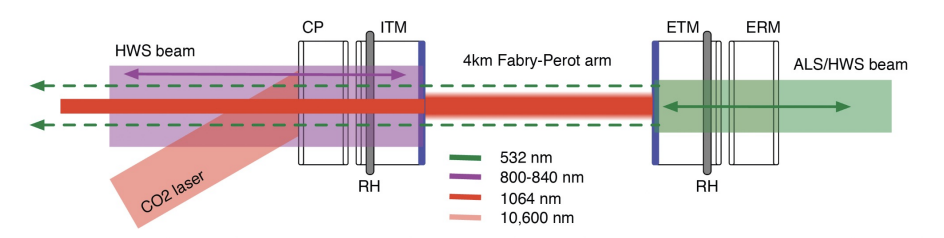

Current LIGO TCS (thermal compensation system without CHETA) adapted from Overview of Advanced LIGO Adaptive Optics by Aidan Brooks et al. 

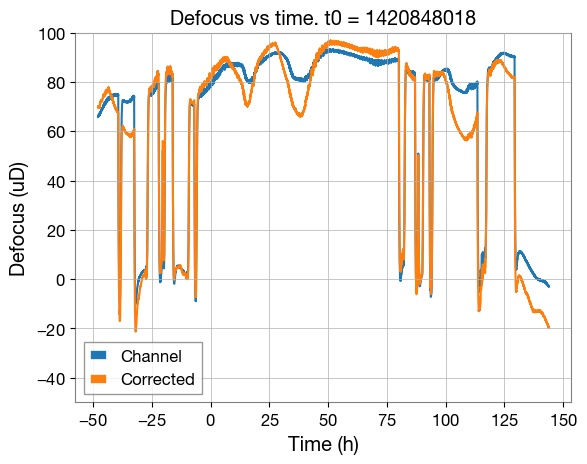 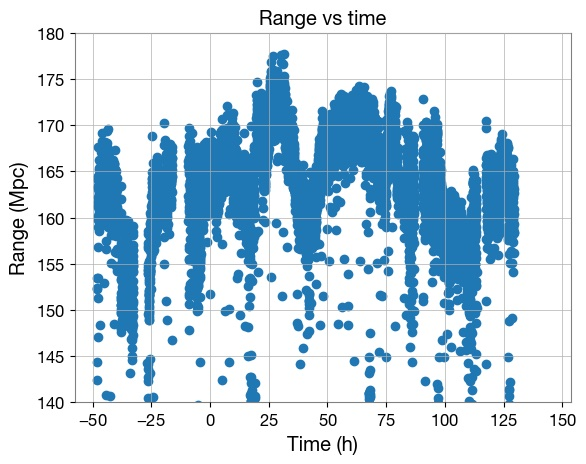

Defocusing due to heating of the mirror (LLO:73011, LLO:74993, LLO:74999 by A. Brooks)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import brentq

# Physical constants
h    = 6.626e-34   # J·s
hbar = h / (2 * np.pi)
c    = 3e8         # m/s
kB   = 1.381e-23   # J/K
eV   = 1.602e-19   # J

plt.rcParams.update({
    'figure.dpi':       120,
    'font.size':        12,
    'axes.labelsize':   13,
    'axes.titlesize':   14,
    'lines.linewidth':  2,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})


---
## 1. Heating vs Cooling

The naive picture: a photon gets absorbed, the atom gets excited, the atom relaxes, a photon comes out.
Energy in equals energy out ; no net heating, no net cooling. So what's the trick?

The key is **entropy**. A laser beam is a highly ordered state of the electromagnetic field ; low entropy per photon. Fluorescence, by contrast, is broadband and spatially isotropic ; high entropy per photon. The second law permits the process as long as the total entropy increases.

More concretely: if the **emitted photon carries more energy** than the absorbed photon (anti-Stokes condition), the extra energy has to come from somewhere. It comes from the phonon bath i.e., the thermal vibrations of the lattice. The solid cools.

The mean fluorescence energy $\langle h\nu_f \rangle$ must exceed the pump photon energy $h\nu_L$:

$$\langle h\nu_f \rangle > h\nu_L$$

The **cooling efficiency** $\eta_c$ is defined as the fraction of absorbed power converted to cooling:

$$\boxed{\eta_c = \eta_{ext} \cdot \frac{\langle \nu_f \rangle}{\nu_L} - 1}$$

where $\eta_{ext}$ is the **external quantum efficiency** (5). This is the fraction of absorbed photons that result in a fluorescent photon escaping the material. For cooling to occur at all, we need $\eta_c > 0$, which means:

$$\eta_{ext} > \frac{\nu_L}{\langle \nu_f \rangle}$$

For Yb³⁺:SiO₂ pumped at 1064 nm with mean fluorescence around 1010 nm, we need $\eta_{ext} \gtrsim 0.95$.

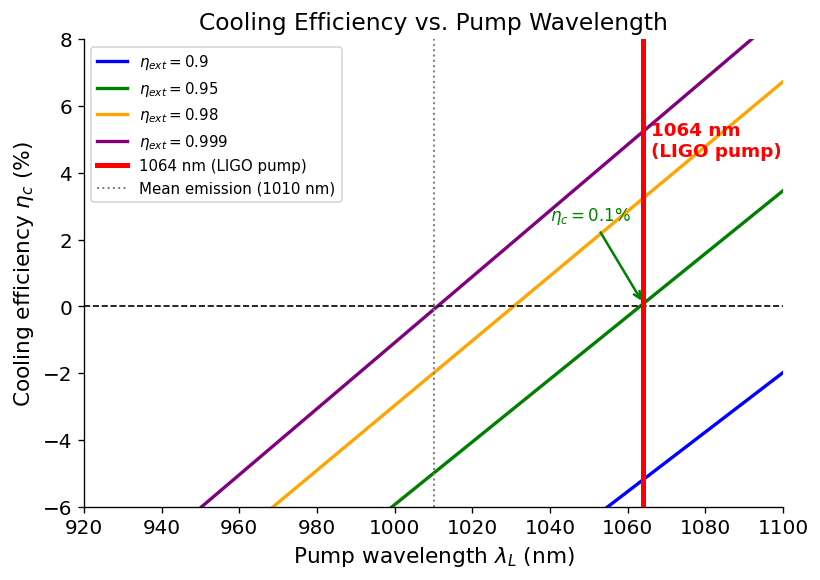

At 1064 nm with η_ext=0.95: η_c = 0.08%


In [2]:
lambda_f_mean = 1010e-9
nu_f_mean     = c / lambda_f_mean

lambda_L = np.linspace(920e-9, 1100e-9, 300)
nu_L     = c / lambda_L

eta_ext_vals = [0.90, 0.95, 0.98, 0.999]
colors       = ['blue', 'green', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(7, 5))

for eta, col in zip(eta_ext_vals, colors):
    eta_c = eta * (nu_f_mean / nu_L) - 1
    ax.plot(lambda_L * 1e9, eta_c * 100, color=col, label=f'$\\eta_{{ext}}={eta}$')

ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.axvline(1064, color='red', linewidth=3, zorder=5, label='1064 nm (LIGO pump)')
ax.text(1066, 4.5, '1064 nm\n(LIGO pump)', fontsize=11, color='red',
        fontweight='bold', zorder=6)

nu_1064    = c / 1064e-9
eta_c_1064 = 0.95 * (nu_f_mean / nu_1064) - 1
ax.annotate(f'$\\eta_c = {eta_c_1064*100:.1f}\\%$',
            xy=(1064, eta_c_1064 * 100),
            xytext=(1040, eta_c_1064 * 100 + 2.5),
            fontsize=10, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.axvline(lambda_f_mean * 1e9, color='gray', linewidth=1.2, linestyle=':',
           label='Mean emission (1010 nm)')

ax.set_xlabel('Pump wavelength $\\lambda_L$ (nm)')
ax.set_ylabel('Cooling efficiency $\\eta_c$ (%)')
ax.set_title('Cooling Efficiency vs. Pump Wavelength')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(-6, 8)
ax.set_xlim(920, 1100)

plt.tight_layout()
plt.show()

print(f'At 1064 nm with η_ext=0.95: η_c = {eta_c_1064*100:.2f}%')

---
## 2. The Energy Level Structure of Yb³⁺

Not all rare-earth ions are created equal for laser cooling. Yb³⁺ is special for a reason that's almost embarrassingly simple: **it has no excited states above the first excited manifold** (within the optical range). This matters enormously.

In most rare-earth ions (Er³⁺, Nd³⁺, Ho³⁺, ...) there are higher-lying electronic states reachable from the first excited state by phonon absorption or excited-state absorption. These provide non-radiative decay channels that dump energy back into the lattice as heat, killing the cooling.

Yb³⁺ has a $4f^{13}$ configuration; just one hole in an otherwise full f-shell. This gives **exactly two manifolds**:
- Ground state: $^2F_{7/2}$ (4 Stark sublevels)
- Excited state: $^2F_{5/2}$ (3 Stark sublevels)

The next electronic state is ~10,000 cm⁻¹ away, making it essentially unreachable.

### 2.1 Inhomogeneous Broadening: The Engine of Anti-Stokes Cooling

In a glass host (amorphous SiO₂), every Yb³⁺ ion sits in a slightly different local environment. This **inhomogeneous broadening** widens both manifolds into bands (~300–500 cm⁻¹ in silica). We pump at the **long-wavelength (cold) edge** of the $^2F_{7/2} \to ^2F_{5/2}$ absorption. The system thermalizes across the excited state band on picosecond timescales, then emits from the thermal average of the excited state; at shorter wavelength than the pump.


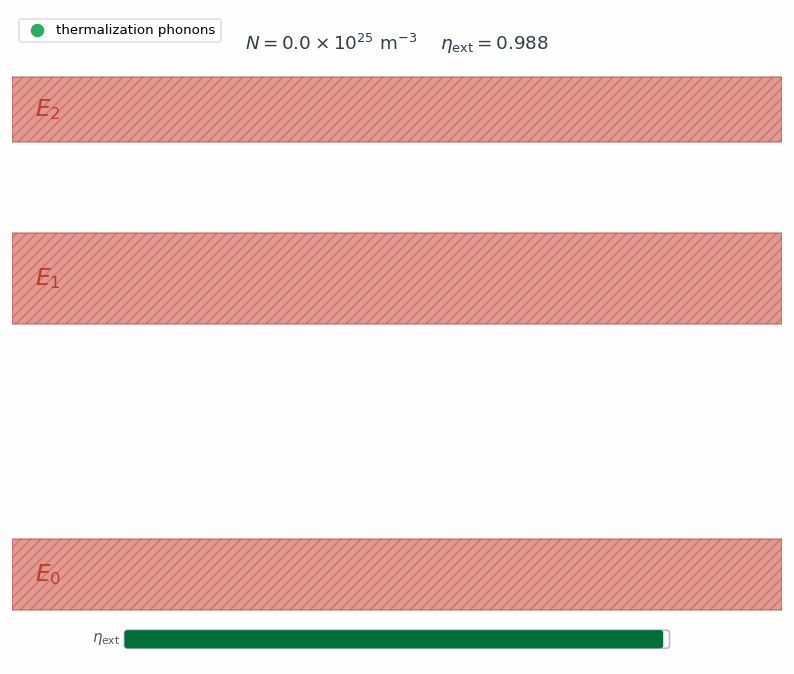

---
## 3. Non-Radiative Losses: What Kills Cooling

The external quantum efficiency $\eta_{ext}$ (1) decomposes as:

$$\eta_{ext} = \eta_{abs} \cdot \eta_{rad} \cdot \eta_{escape}$$

- **$\eta_{abs}$**: fraction of absorbed power into Yb resonant transition (vs. OH⁻, transition-metal impurities, ...)
- **$\eta_{escape}$**: photon actually leaves the material 
- **$\eta_{rad}$**: radiative quantum efficiency i.e., photon emitted vs. non-radiative decay (more on that below)


### Two dominant non-radiative channels

**Multi-phonon decay**: rate $\propto e^{-\alpha_{mp} \Delta E / \hbar\omega_{max}}$. SiO₂ has $\hbar\omega_{max} \approx 1100$ cm⁻¹, so bridging the 10 200 cm⁻¹ gap requires ~9 phonons. This is exponentially suppressed and is very slow.

**Concentration quenching**: at high Yb³⁺ densities, ion–ion energy transfer sends excitation on a random walk that ends at a quenching site. The critical quenching concentration $N_{crit}$ is **unknown for IBS-deposited coatings**.

$$\eta_{rad} = \frac{\Gamma_{rad}}{\Gamma_{rad} + \Gamma_{mp} + k_q N_{Yb}}$$

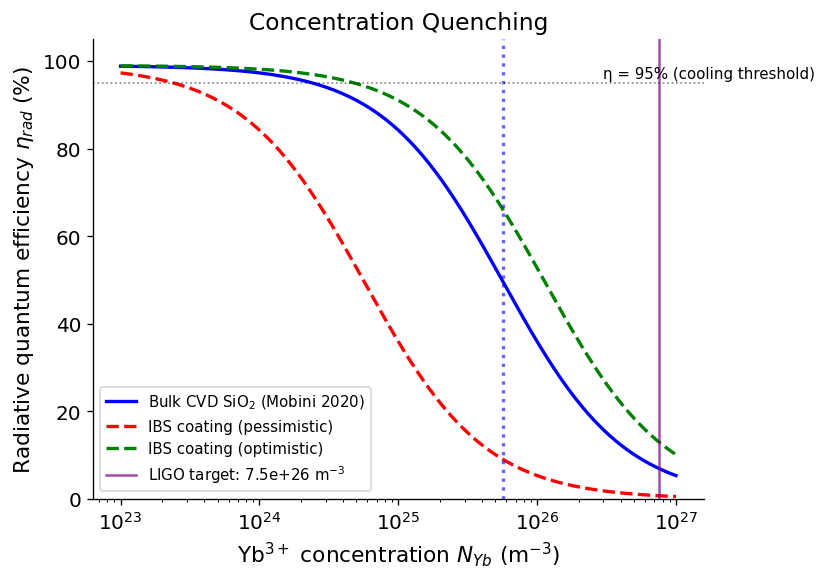

Key question: where does the critical Yb quenching density fall for IBS-deposited coatings?
This is experimentally unknown; one of the central goals of the LIGO cooling proposal.


In [3]:
# Quantum efficiency vs Yb concentration — quenching model

Gamma_rad = 1 / 1e-3    # s^-1  (~1 ms radiative lifetime)
Gamma_mp  = 1 / 100e-3  # s^-1  (multi-phonon, subdominant in SiO2)

N_Yb = np.logspace(23, 27, 500)  # ions / m^3

# Critical concentration for bulk CVD silica (Mobini et al. 2020)
N_crit_bulk = 5.7e25  # m^-3  (~0.13 mol%)
k_q_bulk    = (Gamma_rad + Gamma_mp) / N_crit_bulk

# IBS coating: unknown — bracket with optimistic / pessimistic scenarios
N_crit_IBS_pess = 0.1 * N_crit_bulk
N_crit_IBS_opt  = 2.0 * N_crit_bulk
k_q_pess = (Gamma_rad + Gamma_mp) / N_crit_IBS_pess
k_q_opt  = (Gamma_rad + Gamma_mp) / N_crit_IBS_opt

def eta_rad(N, k_q):
    return Gamma_rad / (Gamma_rad + Gamma_mp + k_q * N)

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogx(N_Yb, eta_rad(N_Yb, k_q_bulk) * 100, 'b-',
            label='Bulk CVD SiO$_2$ (Mobini 2020)')
ax.semilogx(N_Yb, eta_rad(N_Yb, k_q_pess) * 100, 'r--',
            label='IBS coating (pessimistic)')
ax.semilogx(N_Yb, eta_rad(N_Yb, k_q_opt)  * 100, 'g--',
            label='IBS coating (optimistic)')

ax.axvline(N_crit_bulk, color='blue', linestyle=':', alpha=0.6)
ax.axhline(95, color='k', linestyle=':', alpha=0.5, linewidth=1)
ax.text(3e26, 96, 'η = 95% (cooling threshold)', fontsize=9)

N_target = 7.5e26
ax.axvline(N_target, color='purple', linewidth=1.5, alpha=0.7,
           label=f'LIGO target: {N_target:.1e} m$^{{-3}}$')

ax.set_xlabel('Yb$^{3+}$ concentration $N_{Yb}$ (m$^{-3}$)')
ax.set_ylabel('Radiative quantum efficiency $\\eta_{rad}$ (%)')
ax.set_title('Concentration Quenching')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print('Key question: where does the critical Yb quenching density fall for IBS-deposited coatings?')
print('This is experimentally unknown; one of the central goals of the LIGO cooling proposal.')

---
## 4. Heat Budget: From Cooling Efficiency to Temperature Change

The cooling power delivered by the Yb layer:

$$P_{cool} = \eta_c \cdot P_{abs,Yb}$$

For radiation balancing we want $P_{cool} = P_{bg}$, which gives the required resonant absorption:

$$\alpha_{Yb} = \frac{\alpha_{bg}}{\eta_c} \approx \frac{0.5 \text{ ppm}}{0.05} = 10 \text{ ppm}$$

which seems feasible without degrading coating reflectivity.




In [4]:
import ipywidgets as widgets
from IPython.display import display

def plot_radiation_balance(P_circ_kW=400, alpha_bg_ppm=0.5, eta_c_pct=5.0):
    P_circ    = P_circ_kW * 1e3
    alpha_bg  = alpha_bg_ppm * 1e-6
    eta_c     = eta_c_pct / 100

    P_heat_bg     = alpha_bg * P_circ
    alpha_Yb_coat = np.logspace(-7, -4, 200)
    P_cool_coat   = eta_c * alpha_Yb_coat * P_circ
    alpha_balance = alpha_bg / eta_c

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.loglog(alpha_Yb_coat * 1e6, P_cool_coat * 1e3, 'b-', label='Cooling power')
    ax.axhline(P_heat_bg * 1e3, color='red', linestyle='--',
               label=f'Background heating: {P_heat_bg*1e3:.1f} mW '
                     f'({alpha_bg_ppm:.1f} ppm × {P_circ_kW:.0f} kW)')
    ax.axvline(alpha_balance * 1e6, color='green', linestyle=':', linewidth=2,
               label=f'Balance at $\\alpha_{{Yb}}$ = {alpha_balance*1e6:.1f} ppm')

    ax.set_xlabel('Yb resonant absorption $\\alpha_{Yb}$ (ppm)')
    ax.set_ylabel('Cooling power (mW)')
    ax.set_title(f'Radiation Balancing in LIGO Coating\n'
                 f'($P_{{circ}}$ = {P_circ_kW:.0f} kW)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(1e-1, 1e2)
    ax.set_ylim(1e-1, 1e5)

    plt.tight_layout()
    plt.show()

    print(f'Background heating:     {P_heat_bg*1e3:.1f} mW')
    print(f'Required Yb absorption: {alpha_balance*1e6:.2f} ppm')

widgets.interact(
    plot_radiation_balance,
    P_circ_kW    = widgets.FloatSlider(value=400, min=10,  max=1000, step=10,
                                       description='$P_{circ}$ (kW)',
                                       style={'description_width': 'initial'}),
    alpha_bg_ppm = widgets.FloatSlider(value=0.5, min=0.1, max=5.0,  step=0.1,
                                       description='$\\alpha_{bg}$ (ppm)',
                                       style={'description_width': 'initial'}),
    eta_c_pct    = widgets.FloatSlider(value=5.0, min=1.0, max=15.0, step=0.5,
                                       description='$\\eta_c$ (%)',
                                       style={'description_width': 'initial'}),
)

interactive(children=(FloatSlider(value=400.0, description='$P_{circ}$ (kW)', max=1000.0, min=10.0, step=10.0,…

<function __main__.plot_radiation_balance(P_circ_kW=400, alpha_bg_ppm=0.5, eta_c_pct=5.0)>

---
## 5. Fluorescence Escape in Thin Films: A New Complication

In bulk Yb:SiO₂ fluorescent photons emitted in nearly any direction can escape. In a thin film ($d \sim 1$–2 μm, $n \approx 1.45$), photons emitted beyond the critical angle

$$\theta_c = \arcsin\!\left(\frac{1}{n}\right) \approx 43.6°$$

are trapped by total internal reflection and either re-absorbed (heating) or lost at the mirror edge (wasted). The solid angle fraction that escapes from a flat interface is:

$$f_{escape} \approx \frac{1 - \cos\theta_c}{2} \approx \frac{1}{4n^2}$$

The actual escape fraction in the multilayer geometry is modified by the stack reflectivities and requires a full transfer matrix simulation (a modelling task that I am delaying till we see cooling).

Critical angle:               43.6°
Escape fraction (1 interface): 13.8%
Escape fraction (2 interfaces): 27.6% (upper bound)


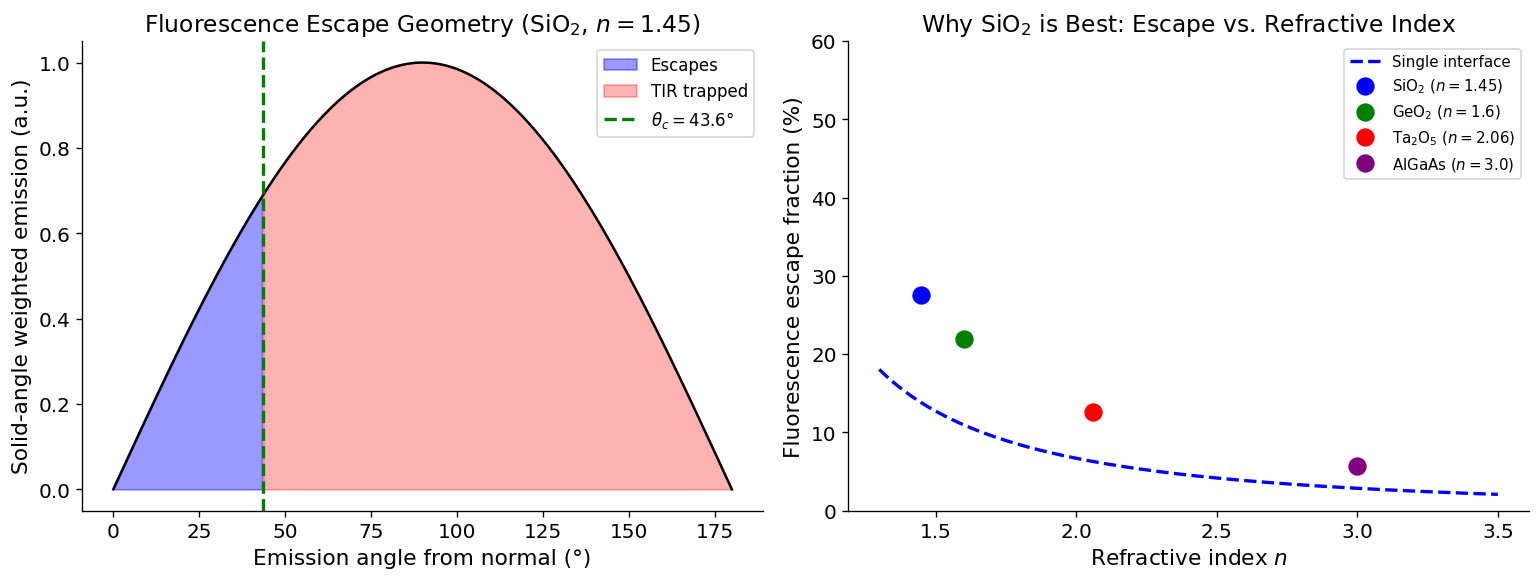

In [5]:
# Fluorescence escape geometry

n_film  = 1.45
theta_c = np.arcsin(1.0 / n_film)
f_esc_1 = (1 - np.cos(theta_c)) / 2
f_esc_2 = 2 * f_esc_1  # both interfaces, upper bound

print(f'Critical angle:               {np.degrees(theta_c):.1f}°')
print(f'Escape fraction (1 interface): {f_esc_1*100:.1f}%')
print(f'Escape fraction (2 interfaces): {f_esc_2*100:.1f}% (upper bound)')

theta = np.linspace(0, np.pi , 500)
dOmega = np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT ; emission angle distribution
ax = axes[0]
ax.fill_between(np.degrees(theta), dOmega,
                where=(theta < theta_c),
                alpha=0.4, color='blue', label='Escapes')
ax.fill_between(np.degrees(theta), dOmega,
                where=(theta >= theta_c),
                alpha=0.3, color='red',  label='TIR trapped')
ax.plot(np.degrees(theta), dOmega, 'k-', linewidth=1.5)
ax.axvline(np.degrees(theta_c), color='green', linestyle='--', linewidth=2,
           label=f'$\\theta_c = {np.degrees(theta_c):.1f}°$')
ax.set_xlabel('Emission angle from normal (°)')
ax.set_ylabel('Solid-angle weighted emission (a.u.)')
ax.set_title('Fluorescence Escape Geometry (SiO$_2$, $n=1.45$)')
ax.legend(fontsize=10)

# RIGHT ; escape fraction vs refractive index
n_range    = np.linspace(1.3, 3.5, 300)
theta_c_n  = np.arcsin(np.minimum(1.0 / n_range, 1.0))
f_esc_both = 2 * (1 - np.cos(theta_c_n)) / 2

ax2 = axes[1]
 
ax2.plot(n_range, (1 - np.cos(theta_c_n)) / 2 * 100, 'b--',
         label='Single interface')

materials = {'SiO$_2$': 1.45, 'GeO$_2$': 1.60, 'Ta$_2$O$_5$': 2.06, 'AlGaAs': 3.0}
mat_colors = ['blue', 'green', 'red', 'purple']
for (mat, n), col in zip(materials.items(), mat_colors):
    tc = np.arcsin(min(1.0 / n, 1.0))
    fe = (1 - np.cos(tc))
    ax2.plot(n, fe * 100, 'o', color=col, markersize=10, label=f'{mat} ($n={n}$)')

ax2.set_xlabel('Refractive index $n$')
ax2.set_ylabel('Fluorescence escape fraction (%)')
ax2.set_title('Why SiO$_2$ is Best: Escape vs. Refractive Index')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.show()

---
## 6. Putting It Together: The Radiation-Balanced Coating

The proposed architecture:

1. Standard $\lambda/4$ HR stack (Ti:Ta₂O₅/SiO₂ or Ti:GeO₂/SiO₂) → R > 99.99% at 1064 nm
2. Top layer of Yb₂O₃:SiO₂, thickness a multiple of $\lambda/2$ (anti-resonant keeping field node at surface)
3. Yb³⁺ resonantly absorbs ~10 ppm of circulating power, re-emits at shorter wavelength
4. Cooling power cancels residual background absorption heat

Full coating efficiency:

$$\eta_c^{coating} = \eta_{abs} \cdot \eta_{rad} \cdot \eta_{escape}^{multilayer} \cdot \frac{\langle\nu_f\rangle}{\nu_L} - 1$$

### Thermal noise: the constraint nobody can ignore

The fluctuation-dissipation theorem links any dissipation to position noise. Fused silica has the lowest mechanical loss of any amorphous coating material and this is **not a coincidence**: the same network structure (large corner-sharing rings, low phonon–phonon coupling) that suppresses multi-phonon non-radiative decay also suppresses two-level-system mechanical loss. The Yb layer must not degrade this. Still working on getting an approximate value for this noise.

Antinode positions (μm): ['0.092', '0.459', '0.826', '1.192', '1.559']


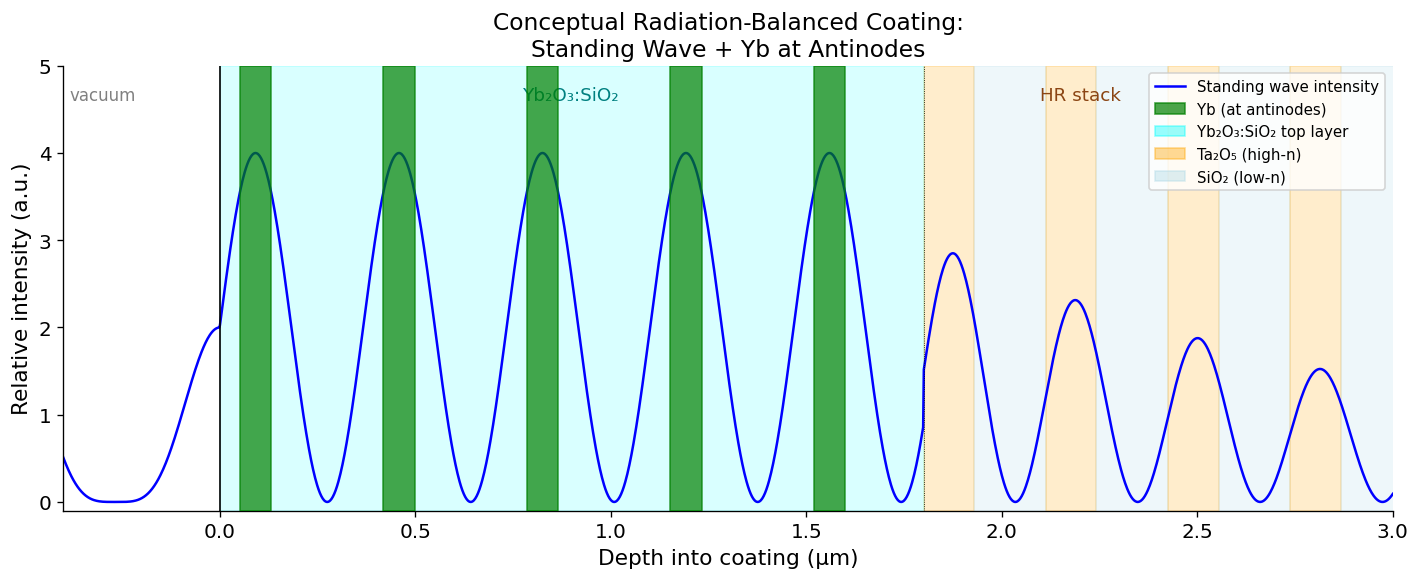

In [6]:
from scipy.signal import find_peaks
import matplotlib.patches as mpatches

z = np.linspace(-0.5e-6, 3.0e-6, 2000)
k = 2 * np.pi / 1064e-9

d_top = 1.8e-6
d_hi  = 1064e-9 / (4 * 2.06)
d_lo  = 1064e-9 / (4 * 1.45)

def standing_wave(z, d_top, d_hi, d_lo):
    I = np.zeros_like(z)
    for i, zi in enumerate(z):
        if zi < 0:
            I[i] = 0.5 * (1 + np.cos(2 * k * zi))**2
        elif zi < d_top:
            I[i] = 2.0 * (1 + np.sin(2 * 1.45 * k * zi))
        else:
            dz    = zi - d_top
            decay = np.exp(-dz / 1.5e-6)
            I[i]  = 1.5 * decay * (1 + np.sin(2 * 1.7 * k * dz))
    return I

I_sw = standing_wave(z, d_top, d_hi, d_lo)

# Antinode positions — shifted by quarter wavelength
n_yb             = 1.45
lambda_sw        = 1064e-9 / n_yb
antinode_spacing = lambda_sw / 2
quarter          = antinode_spacing /4

antinodes = []
m = 0
while True:
    z_an = quarter + m * antinode_spacing
    if z_an > d_top:
        break
    antinodes.append(z_an)
    m += 1

print(f'Antinode positions (μm): {[f"{z*1e6:.3f}" for z in antinodes]}')

fig, ax = plt.subplots(figsize=(12, 5))

# Layer background shading
ax.axvspan(0, d_top * 1e6, alpha=0.15, color='cyan')
current_z = d_top
is_hi = True
for _ in range(10):
    d     = d_hi if is_hi else d_lo
    color = 'orange' if is_hi else 'lightblue'
    ax.axvspan(current_z * 1e6, (current_z + d) * 1e6, alpha=0.2, color=color)
    current_z += d
    is_hi = not is_hi
    if current_z > 3e-6:
        break

# Standing wave
ax.plot(z * 1e6, I_sw, 'b-', linewidth=1.5, label='Standing wave intensity')

# Yb strips at antinodes
strip_width_um = 0.04
for z_an in antinodes:
    z_an_um = z_an * 1e6
    ax.axvspan(z_an_um - strip_width_um, z_an_um + strip_width_um,
               alpha=0.7, color='green', zorder=4)

# Boundary lines
ax.axvline(0,           color='k', linewidth=1)
ax.axvline(d_top * 1e6, color='k', linewidth=0.5, linestyle=':')

# Labels
ax.text(0.9,  4.6, 'Yb₂O₃:SiO₂', fontsize=11, ha='center', color='teal')
ax.text(2.2,  4.6, 'HR stack',    fontsize=11, ha='center', color='saddlebrown')
ax.text(-0.3, 4.6, 'vacuum',      fontsize=10, ha='center', color='gray')

ax.set_xlabel('Depth into coating (μm)')
ax.set_ylabel('Relative intensity (a.u.)')
ax.set_title('Conceptual Radiation-Balanced Coating:\nStanding Wave + Yb at Antinodes')
ax.set_xlim(-0.4, 3.0)
ax.set_ylim(-0.1, 5.0)

# Legend
yb_patch = mpatches.Patch(color='green',     alpha=0.7, label='Yb (at antinodes)')
cy_patch = mpatches.Patch(color='cyan',      alpha=0.4, label='Yb₂O₃:SiO₂ top layer')
hi_patch = mpatches.Patch(color='orange',    alpha=0.4, label='Ta₂O₅ (high-n)')
lo_patch = mpatches.Patch(color='lightblue', alpha=0.4, label='SiO₂ (low-n)')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [yb_patch, cy_patch, hi_patch, lo_patch],
          fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

---
## 7. Conclusions

### Things we don't know yet

1. **Critical Yb quenching concentration in IBS-deposited SiO₂.** Bulk CVD silica saturates around $N_{crit} \sim 6 \times 10^{25}$ m⁻³. The LIGO proposal needs 2 mol% ($\sim 7.5 \times 10^{26}$ m⁻³). This is well above the bulk limit. The IBS amorphous network is different; this could be better or worse. Most pressing experimental question.

2. **How does Yb incorporate into the IBS SiO₂ network?** Does Yb³⁺ substitute Si⁴⁺ (charge compensation needed; possibly Al co-doping)? Or does it cluster? Answer determines both quantum efficiency and mechanical loss.

3. **Fluorescence escape efficiency in the multilayer geometry.** Full transfer matrix calculation needed. The geometric estimate here is a floor, not a prediction.

4. **Thermal noise impact.** The Yb layer must not degrade mechanical loss below LIGO test-mass specification. Direct GeNS ringdown measurement essential.



### Things worth thinking about

- If IBS quenching is worse than bulk, could **spatial engineering** (matching Yb profile to field antinodes via ion implantation) allow higher area density at lower concentration and does that actually help the cooling?
- The fluorescent light adds white noise (in the form of scattering) at $\sim 1.2 \times$ $10^{-21}$ $m/Hz^{1/2}$ i.e., ~10× below LIGO A+ sensitivity. Coincidence?
- Could a **resonant cavity for the fluorescent light** (engineered layer thicknesses preferentially coupling specific angular modes) improve $\eta_{escape}$?

---
## Summary

| Parameter | Bulk Yb:SiO₂ (CVD) | Target for IBS Coating |
|-----------|--------------------|-----------------------|
| Cooling efficiency $\eta_c$ | 4–6% | ~5% |
| External QE $\eta_{ext}$ | ~97% | >95% |
| Max Yb concentration | $6 \times 10^{25}$ m⁻³ | $7.5 \times 10^{26}$ m⁻³ |
| Cooling achieved | 67 K below RT | 0.2-0.6K requirement (aLIGO) |
| Pump wavelength | 1020–1030 nm | 1064 nm (LIGO operational) |
| Status | Demonstrated (2024) | Hopefully will demonstrate 2026? |

The IBS coating program is trying to do something that has never been done: embed a working laser refrigerator into a mirror. The physics says it's possible. Whether the materials cooperate is an open question.

---
## References

1. Mobini, E. et al., *Laser cooling of ytterbium-doped silica glass*, Commun. Phys. **3**, 134 (2020)
2. Topper, B. et al., *Laser cooling ytterbium doped silica by 67 K from ambient temperature*, Opt. Express **32**, 3660 (2024)
3. Ballmer, S.W., *Photothermal transfer function of dielectric mirrors for precision measurements*, Phys. Rev. D **91**, 023010 (2015)
4. Komori, K. et al., *Direct approach for the fluctuation-dissipation theorem under nonequilibrium steady-state conditions*, Phys. Rev. D **97**, 102001 (2018)
5. Epstein, R.I. et al., *Observation of laser-induced fluorescent cooling of a solid*, Nature **377**, 500 (1995)

